In [ ]:
from ultralytics import YOLO

yolo = YOLO("yolov8x.pt") 

In [ ]:
def yolo_has_person(image):
    results = yolo(image, imgsz=1280, conf=0.1)

    boxes = results[0].boxes
    if boxes is None:
        return False, 0.0

    classes = boxes.cls.tolist()
    confs = boxes.conf.tolist()

    person_confs = [
        c for cls, c in zip(classes, confs)
        if int(cls) == 0
    ]

    if len(person_confs) == 0:
        return False, 0.0

    return True, max(person_confs)

In [3]:
import torch
import open_clip
from PIL import Image

clip_model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="laion2b_s34b_b79k"
)

tokenizer = open_clip.get_tokenizer("ViT-B-32")

e:\OneDrive\Pulpit\MSC-thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
TEXTS = [
    "an image containing people",
    "an image with no people",
]

In [5]:
with torch.no_grad():
    text_tokens = tokenizer(TEXTS)
    text_features = clip_model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

In [14]:
def clip_has_person(image):
    image = preprocess(image).unsqueeze(0)

    with torch.no_grad():
        img_feat = clip_model.encode_image(image)
        img_feat /= img_feat.norm(dim=-1, keepdim=True)

        logits = (img_feat @ text_features.T).softmax(dim=-1)
        probs = logits[0].tolist()

    return probs[0], probs[1]  # person, no-person

In [11]:
def hybrid_predict(image):
    yolo_found, _ = yolo_has_person(image)
    clip_person, _ = clip_has_person(image)

    # 1. YOLO is high precision → trust it if it fires
    if yolo_found:
        return True

    # 2. fallback to CLIP
    if clip_person > 0.6:
        return True

    return False

In [9]:
hybrid_predict(r"data\jhu_crowd_v2.0\test\images\0104.jpg")


image 1/1 e:\OneDrive\Pulpit\MSC-thesis\data\jhu_crowd_v2.0\test\images\0104.jpg: 736x1280 9 cars, 2 buss, 6 trucks, 2 tvs, 6239.0ms
Speed: 23.2ms preprocess, 6239.0ms inference, 27.1ms postprocess per image at shape (1, 3, 736, 1280)


(False, {'method': 'fusion', 'confidence': 0.4933822453022003})

In [1]:
%load_ext autoreload
%autoreload 2
import torch
from training_functions import train, evaluate_mae_mse
from mcnn import MCNN
import torch.nn as nn
import torch.optim as optim
from dataloader_mcnn import CrowdDataset
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
import glob
import os
import numpy as np
import random
import time
import pandas as pd
import cv2
SEED = 42

In [29]:
main_folders = [r"data\ShanghaiTech_part_A\test", 
                r"data\ShanghaiTech_part_B\test",
               r'data\NWPU-Crowd\val',
              r"data\UCF-QNRF_ECCV18\test",
               r"data\jhu_crowd_v2.0\test",
               r"data\UCF_CC_50"]

gt_labels = []
pred_labels = []
for folder in main_folders:
    evaluations = []    
    test_img_root = os.path.join(folder, "images")
    test_map_root = os.path.join(folder, "maps")
    test_dataset = CrowdDataset(test_img_root, test_map_root, gt_downsample=1)
    for i,(img,gt_dmap) in enumerate(test_dataset):
        gt_labels.append(gt_dmap.sum().item() > 0)
        img = img.float()

        img = torch.nn.functional.interpolate(
            img.unsqueeze(0),
            size=(1280, 1280),
            mode="bilinear",
            align_corners=False
        )

        pred_labels.append(hybrid_predict(img))


0: 1280x1280 44 persons, 2 cars, 2 buss, 1 dog, 1 handbag, 8513.1ms
Speed: 0.2ms preprocess, 8513.1ms inference, 42.6ms postprocess per image at shape (1, 3, 1280, 1280)


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 1, 3, 224, 224]

In [3]:
main_folders = [r"data\ShanghaiTech_part_A\test", 
                r"data\ShanghaiTech_part_B\test",
               r'data\NWPU-Crowd\val',
              r"data\UCF-QNRF_ECCV18\test",
               r"data\jhu_crowd_v2.0\test",
               r"data\UCF_CC_50"]

images = []
for folder in main_folders:
    test_img_root = os.path.join(folder, "images")
    test_map_root = os.path.join(folder, "maps")
    test_dataset = CrowdDataset(test_img_root, test_map_root, gt_downsample=1)
    for i,(img,gt_dmap) in enumerate(test_dataset):
        if gt_dmap.sum().item() == 0:
            images.append(img)

In [4]:
print(len(images))

39


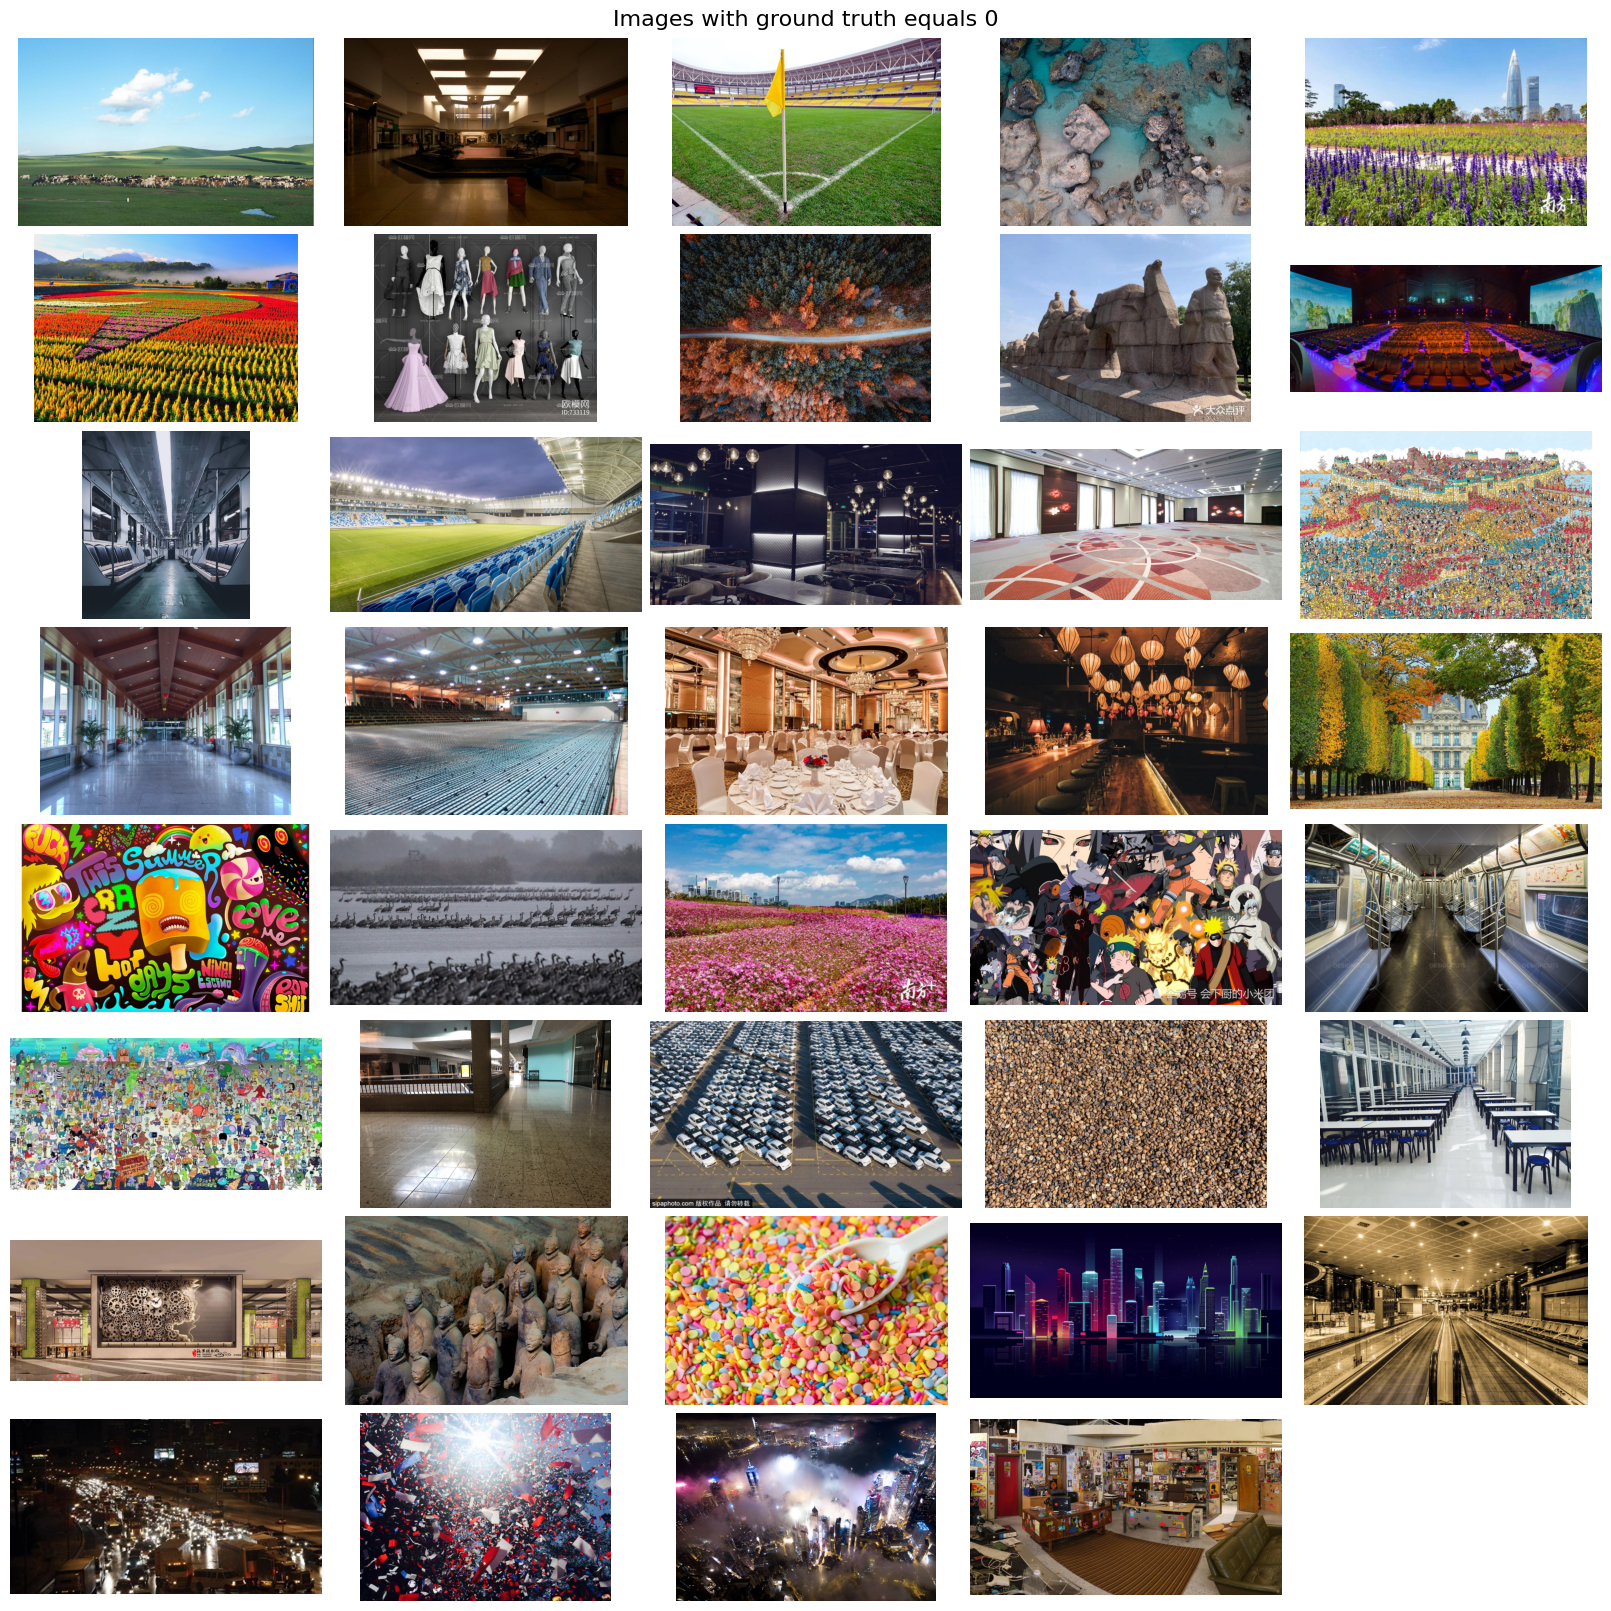

In [15]:
n = len(images)

rows = 8
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(16, rows*2), constrained_layout=True)
axes = axes.flatten()

for i in range(rows * cols):
    ax = axes[i]
    ax.axis("off")

    if i < n:
        img = images[i]
        if img.ndim == 3 and img.shape[0] in [1, 3]:
            img = img.permute(1, 2, 0)
        if img.ndim == 3 and img.shape[2] == 1:
            img = img.squeeze(-1)

        ax.imshow(img)

for i in range(n, rows * cols):
    axes[i].set_visible(False)

fig.suptitle("Images with ground truth equals 0", fontsize=16)
plt.show()